#### Local Outlier Factor

1.  Local Outlier Factor is an unsupervised anamoly detection algorithm that is used to detect  the outliers from the dataset.

#### Principle behind LOF :-------

(i.)    Here the density of each data point is compared with the data points of its neighbors.

        (a.)    If the density of the data point is much less than its neighbors then it is an outlier

        (b.)    If the density of the data point is same as the neighbors, then it is the normal data point.

#### Use cases of Local Outlier Factor :--------------

(a.)    Credit Card Fraud Detection System

#### Problem Statement :-----

1.  Develop an Anamoly based system on breast cancer dataset using Local Outlier Factor algorithm and predict

    (a.)    all the outliers

    (b.)    display and visualize the outliers and LOF scores


#### Step 1: Import all the necessary libraries

In [962]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.datasets             import     load_breast_cancer
from    sklearn.model_selection      import     train_test_split
from    sklearn.preprocessing        import     StandardScaler
from    sklearn.neighbors            import     LocalOutlierFactor
from    sklearn.decomposition        import     PCA

#### Step 2:    Load the dataset

In [963]:
#### extract the data

data = load_breast_cancer()

#### constuct the dataframe from the data
df = pd.DataFrame(data.data, columns=data.feature_names)

#### Add the target to the dataset
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


#### OBSERVATIONS:

1.  There are total 569 records in the dataset.

2.  The dataset has 569 rows and 31 columns.

3.  ### Dataset Interpretation 

| Column Name             | One-Line Explanation                                                 |
| ----------------------- | -------------------------------------------------------------------- |
| mean radius             | Average distance from the center to the perimeter of the tumor cells |
| mean texture            | Average variation in gray-scale intensity of the cell image          |
| mean perimeter          | Average perimeter length of the tumor nucleus                        |
| mean area               | Average area occupied by the tumor nucleus                           |
| mean smoothness         | Average smoothness of cell boundaries                                |
| mean compactness        | Average compactness = perimeter² / area − 1                          |
| mean concavity          | Average severity of concave portions in the contour                  |
| mean concave points     | Average number of concave portions of the contour                    |
| mean symmetry           | Average symmetry of the cell shape                                   |
| mean fractal dimension  | Average complexity of boundary shape                                 |
| radius error            | Standard error of radius measurements                                |
| texture error           | Standard error of texture measurements                               |
| perimeter error         | Standard error of perimeter measurements                             |
| area error              | Standard error of area measurements                                  |
| smoothness error        | Standard error of smoothness measurements                            |
| compactness error       | Standard error of compactness measurements                           |
| concavity error         | Standard error of concavity measurements                             |
| concave points error    | Standard error of concave point measurements                         |
| symmetry error          | Standard error of symmetry measurements                              |
| fractal dimension error | Standard error of fractal dimension measurements                     |
| worst radius            | Largest/worst radius observed                                        |
| worst texture           | Largest/worst texture value observed                                 |
| worst perimeter         | Largest/worst perimeter observed                                     |
| worst area              | Largest/worst area observed                                          |
| worst smoothness        | Largest/worst smoothness value observed                              |
| worst compactness       | Largest/worst compactness value observed                             |
| worst concavity         | Largest/worst concavity value observed                               |
| worst concave points    | Largest/worst concave points value observed                          |
| worst symmetry          | Largest/worst symmetry value observed                                |
| worst fractal dimension | Largest/worst fractal dimension value observed                       |
| target                  | Type of the breast cancer whether malignant or benign                |

#### Step 3: Perform the Data Exploration

In [964]:
#### get the first five records of the dataset

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [965]:
#### get the last five records of the dataset

df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [966]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 569


In [967]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (569, 31)


In [968]:
#### get the columns used in the dataset

print(df.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='str')


In [969]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

#### OBSERVATIONS:

1.  All the independent features are floating in nature.

2.  But the target variable (target) is integer in nature.

In [970]:
#### get the descriptive summary statistics for each numerical column used in the dataset

df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


#### OBSERVATIONS:

1.  The above table explains about the statistical infromation for each numerical column used in the dataset.

In [971]:
#### get the count of categories in the target column

df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

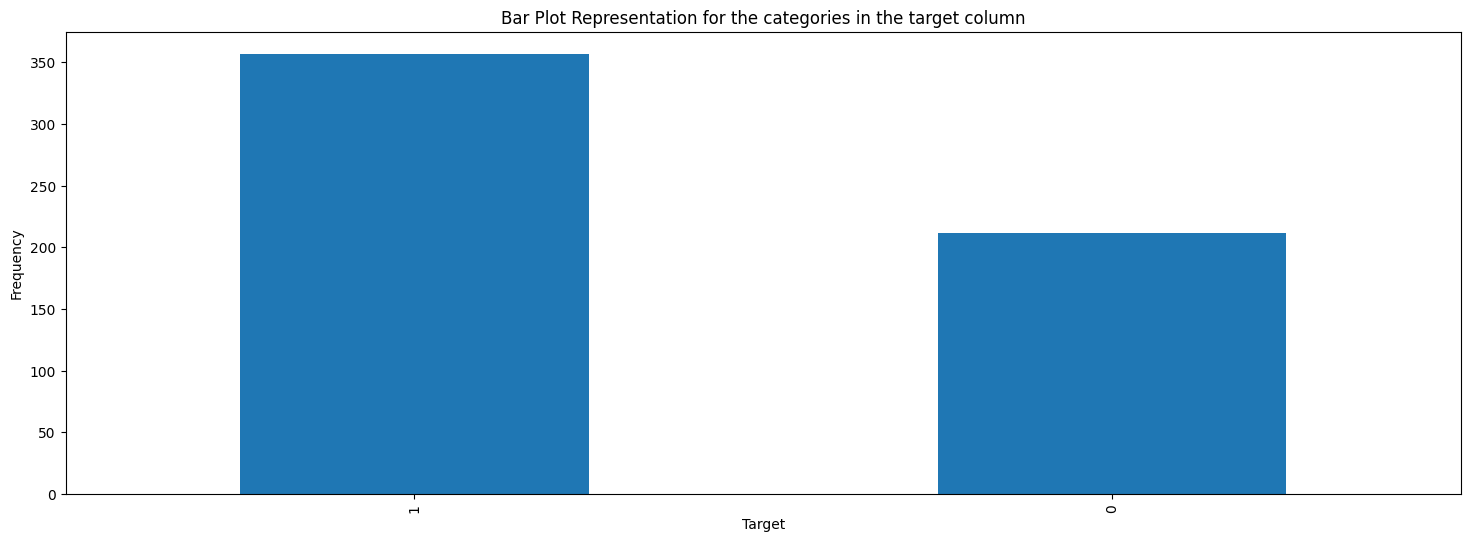

In [972]:
#### perform the graphical visualization for the categorical count of all the categories in the target column

plt.figure(figsize=(18,6))
df['target'].value_counts().plot(kind='bar')
#### get the title of the graph
plt.title("Bar Plot Representation for the categories in the target column")
#### get the x axis of the graph
plt.xlabel("Target")
#### get the y-axis of the graph
plt.ylabel("Frequency")
#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts the frequency count of eac category in the target column.

2.  The count of target 1 is 357 and the count of target 2 is 212.

3.  So the target 1 is much higher in number than the target 2.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [973]:
#### To check for all the NULL records in the dataset

df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

#### OBSERVATIONS:

1.  There are no null records used in the dataset.

In [974]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [975]:
#### Drop the unwanted column from the dataset

df.drop(columns='target',inplace=True)

#### OBSERVATIONS:

1.  The column 'target' has been removed from the dataset. This is because

    (a.) target is the dependent variable of the dataset. But here we are performing an unsupervised anamoly detection algorithm named "Local Outlier Factor (LOF)"

    (b.) As we are performing LOF algorithm on the data, it will work on the input not on the output.

    (c.) LOF will not produce any target values during the model training.  

In [976]:
#### Again check the data

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#### OBSERVATIONS:

1.  The target column has been completely removed from the dataset.

#### Step 5: Perform Exploratory Data Analysis

In [977]:
#### get the correlation between all the numerical columns used in the dataset

df.corr()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


#### OBSERVATIONS:

1.  The above table explains the correlation for each numerical column with respect to each other in the dataset.

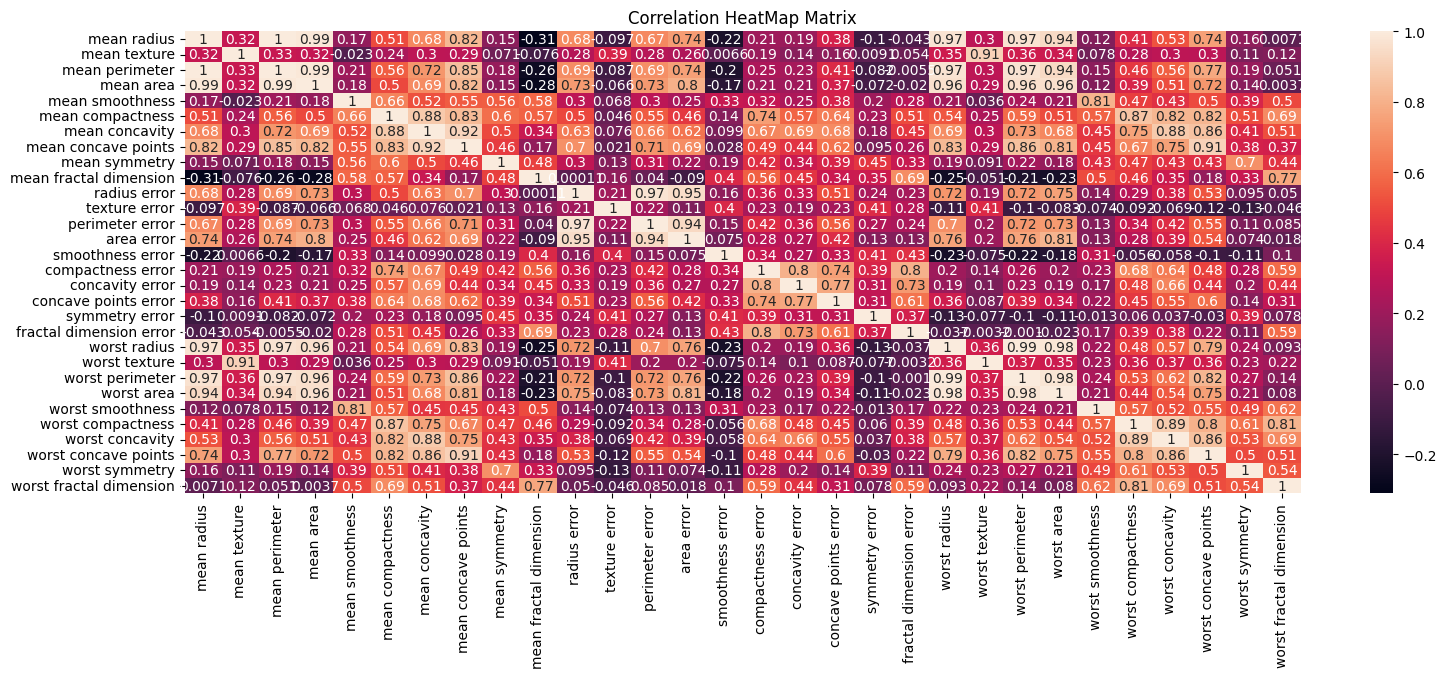

In [978]:
#### get the graphical representation for the correlation between all the numerical columns used in the dataset

plt.figure(figsize=(18,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation HeatMap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above table depicts the graphical representation for the correlation between the numrical columns used in the dataset.

#### Step 6: Perform Feature Scaling on the inputs

In [979]:
from sklearn.preprocessing  import StandardScaler

#### create an object of Standard Scaler
sc = StandardScaler()

#### Scale the entire dataset
X_scaled = sc.fit_transform(df)

In [980]:
print(X_scaled)

[[ 1.09706398 -2.07333501  1.26993369 ...  2.29607613  2.75062224
   1.93701461]
 [ 1.82982061 -0.35363241  1.68595471 ...  1.0870843  -0.24388967
   0.28118999]
 [ 1.57988811  0.45618695  1.56650313 ...  1.95500035  1.152255
   0.20139121]
 ...
 [ 0.70228425  2.0455738   0.67267578 ...  0.41406869 -1.10454895
  -0.31840916]
 [ 1.83834103  2.33645719  1.98252415 ...  2.28998549  1.91908301
   2.21963528]
 [-1.80840125  1.22179204 -1.81438851 ... -1.74506282 -0.04813821
  -0.75120669]]


#### OBSERVATIONS:

1.  Local Outlier Factor(LOF) is a distance based algorithm, so here feature scaling is required.

2.  Here as it is an unsupervised anamoly detection algorithm, so no output is there. The dataset is not divided into independent and dependent features

3.  This model does not perform predictive learning rather it just compares the density of the data point with the density of its neighbouring point.

#### Step 7: Apply LOF

In [981]:
#### Create an object for Local Outlier Factor

lof = LocalOutlierFactor(
    n_neighbors     =   20       ,
    contamination   =   0.05
)

#### OBSERVATIONS:

1.  The object of Local Outlier Factor (LOF) has been created with the help of following parameters :-----

    (a.)    n_nighbors = 20 ==================> Total number of neighbors around each data point for density comparision.

    (b.)    contamination = 0.05 =============> Expected proportions of anamolies in the dataset.

In [982]:
#### using the object of LOF, train and predict the model

Y_pred = lof.fit_predict(X_scaled)

In [983]:
Y_pred

array([ 1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
       -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

#### OBSERVATIONS:

1.  The output is predicted for the given input and the data points are classified as:-----

    (a.) Normal data points =====================> 1

    (b.) Outliers           =====================> -1

#### Step 8: Count the Outliers

In [984]:
outlier_count = np.sum(Y_pred == -1)

normal_count  = np.sum(Y_pred == 1)

In [985]:
print("Outlier Data Points are:", outlier_count)

print("Normal Data Points are:", normal_count)

Outlier Data Points are: 29
Normal Data Points are: 540


#### Step 9: Add Prediction to DataFrame

In [986]:
#### Add the predicted label to the dataframe

df['Predicted_Label'] = Y_pred

In [987]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Predicted_Label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,-1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


#### OBSERVATIONS:

1.  The predicted label has been added to the dataset.

#### Step 10:  Perform PCA for dimensionality reduction

In [988]:
from sklearn.decomposition import PCA

#### Create an object for PCA
pca = PCA(n_components=2)


#### Apply PCA on the dataset
X_scaled_pca = pca.fit_transform(X_scaled)

In [989]:
X_scaled_pca

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]], shape=(569, 2))

#### OBSERVATIONS:

1. The object of PCA has been created with the following parameters :---

    (a.) n_components = 2 =============> Total number of components to be reduced to 2 for dimensionality reduction.

2. Then this object of PCA has been applied on the input scaled data to reduce the total 30 dimensions to 2 dimensions.

#### Step 11: Plot the Outliers

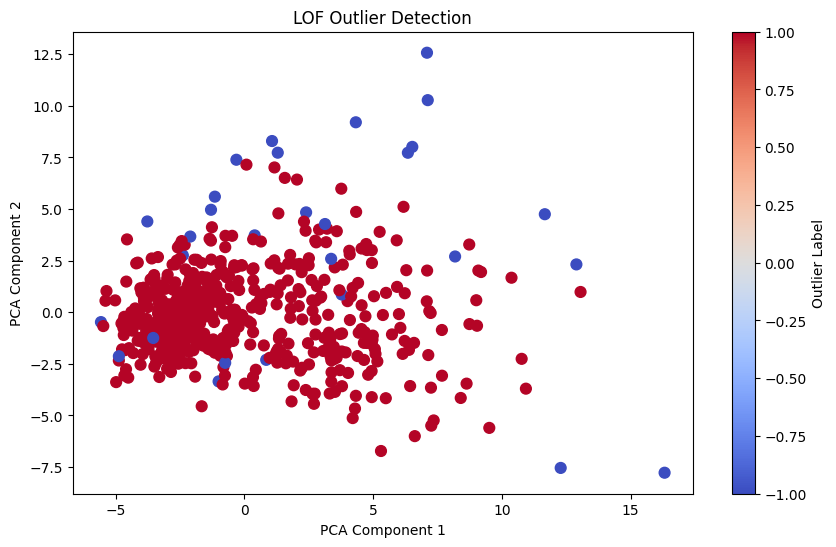

In [990]:
plt.figure(figsize=(10,6))

#### perform the scatter plot for displaying the outliers
plt.scatter(
    X_scaled_pca[:,0]                       ,
    X_scaled_pca[:,1]                       ,
    c           =       Y_pred              ,
    cmap        =       'coolwarm'          ,
    s           =       60
)

#### give the title of the graph
plt.title("LOF Outlier Detection")

#### give the x axis of the graph
plt.xlabel("PCA Component 1")

#### give the y axis of the graph
plt.ylabel("PCA Component 2")

plt.colorbar(label='Outlier Label')

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts the LOF Outlier plots for the two PCAs

2.  The first PCA is plotted in the x axis and the second PCA is plotted in y axis.

3.  The color are plotted based on the predicted labels

    (a.)    1 ==============>  Normal data points

    (b.)    -1 =============>  Outlier

4.  The blue points are the normal data points and the red data points are te outliers.

5.  From this graph, it is seen that there are more number of anamolies than the normal data points.

6.  Maximum number of anamolies lies between  -5 to 0.

#### Step 12: Compute the LOF Scores

In [991]:
#### Anamoly score

score = lof.negative_outlier_factor_

print("LOF Scores are:", score)

LOF Scores are: [-1.37063883 -1.04900658 -1.00465356 -1.84981795 -1.144804   -1.08066595
 -0.99538794 -1.04353394 -1.06242036 -1.65569052 -1.0824647  -1.01894949
 -1.61636405 -1.19687281 -1.14121428 -1.11659342 -1.01793488 -1.02830247
 -1.05659535 -1.02865177 -1.03880952 -1.09029848 -1.32789083 -1.08055238
 -1.05009644 -1.37782688 -1.08399437 -1.03030057 -1.03786061 -1.01631619
 -1.0141982  -1.17112259 -1.02531744 -1.08506508 -1.03877849 -1.14288456
 -1.01621999 -1.28989487 -2.03267551 -1.02505545 -1.03231062 -1.21018896
 -1.50181417 -1.01764644 -1.07553744 -1.07783091 -1.11482817 -1.0149651
 -1.01706803 -1.00443871 -1.002368   -0.9895301  -0.99397194 -1.05793858
 -1.03993657 -1.06223061 -0.99494468 -0.99749612 -1.05396985 -1.22261215
 -1.52570578 -1.24169661 -1.14203166 -1.3958629  -1.00536556 -0.9996208
 -1.0788806  -1.01539145 -1.93880256 -1.0038862  -1.03799898 -1.73915382
 -1.1286007  -1.03214839 -0.95380702 -1.09792006 -1.4863861  -1.21914292
 -1.56077823 -0.97146791 -1.10508878 

#### OBSERVATIONS:

1.  The above data depicts the lof scores of the model.

2.  Lower the LOF score, higher is the anamoly of the model.

3.  #### LOF Score Interpretation:

| Score         | Meaning        |
| ------------- | -------------- |
| Near -1       | Normal         |
| Very Negative | Strong Outlier |


#### Step 13: Visualizing LOF Scores

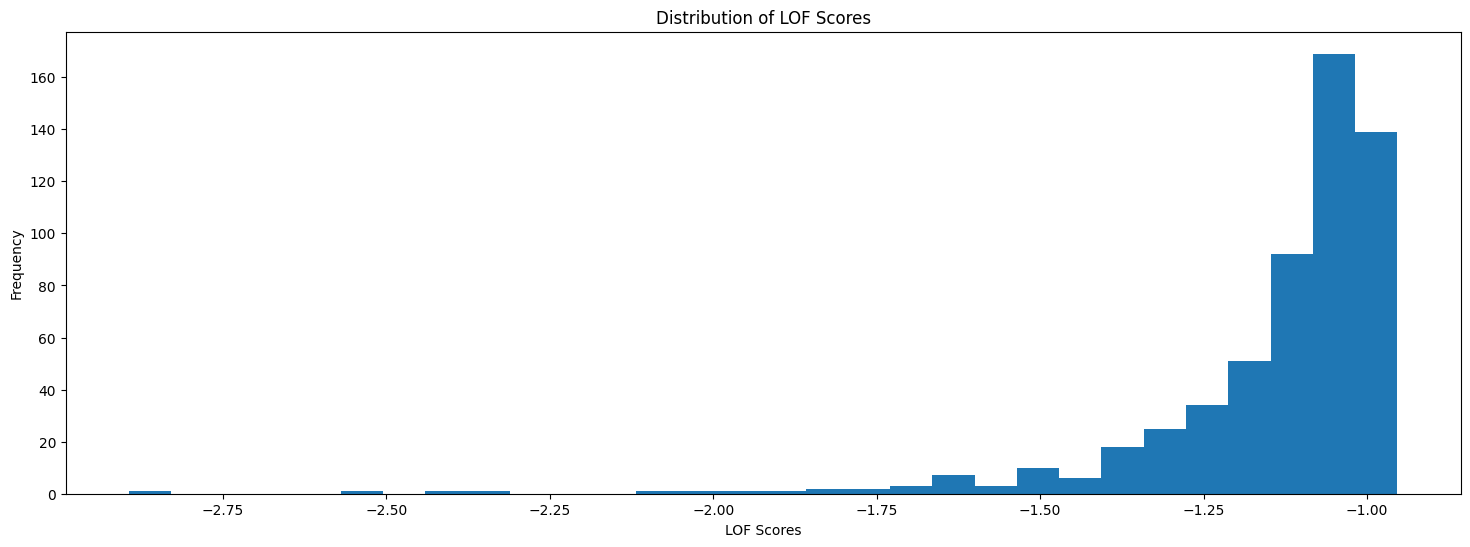

In [992]:
plt.figure(figsize=(18,6))

#### plot the lof scores
plt.hist(score, bins=30)

#### get the title of the graph
plt.title("Distribution of LOF Scores")

#### get the x-axis of the graph
plt.xlabel("LOF Scores")

#### get the y-axis of the graph
plt.ylabel("Frequency")

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts the LOF Score vs the frequency.

2.  Maximum number of lof scores are towards -1 which means that the lof scores are normal.